# Random Forest

   We try to train the Random forest model with different configurations so that we can see which configuration will give the best result, Some forecasts up to 30 minutes are done too.
    
   1- First : we transform this problem of predicting A(t)= RF(A(t-1)) into an easier problem of predicting the difference :  ***A(t+1) = A(t) + RF(A(t) - A(t-1))***. 
    
   2- Once we had the results of this we tryed to check for autocorrelation and added lags to the model and it became : ***A(t+1) = A(t) + RF(A(t) - A(t-1), A(t-4) - A(t-5))***.
   
   Note: here A refers to the macroscopic energy value at the center of the macroscopic pulse (The maximum value of A at time t)

### Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time 
import joblib
import os

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
base_dir = "predictions"
model_name = "random_forest"

model_dir = os.path.join(base_dir, model_name)
os.makedirs(model_dir, exist_ok=True)

### Data Preprocessing

We will create our datasets one for each problem as described in the header, we will save them to be reused for other models.

In [3]:
df = pd.read_csv("../../noise/macro_noisy.csv")

df.head()

,t[s],x_t,y_t,A_sample,A_mean,A_var,A_max,A_min,macro_step_time[s],A_sample_noisy,A_mean_noisy,A_max_noisy,A_min_noisy
0,2.0,20000.0,20000.0,0.999768,0.013218,0.006433,0.999768,-2.829959e-46,0.142123,0.989995,0.008331,0.991949,-0.007819
1,62.0,21000.0,21000.0,0.987603,0.013139,0.006353,0.987603,-2.093811e-45,0.066945,0.976038,0.007356,0.978351,-0.009252
2,122.0,21000.0,21000.0,0.985019,0.013060,0.006274,0.985019,-2.183982e-05,0.124839,0.976572,0.008837,0.978261,-0.006779
3,182.0,22000.0,22000.0,0.979262,0.012982,0.006196,0.979262,-1.562805e-04,0.077798,0.968470,0.007586,0.970628,-0.008790
4,242.0,22000.0,22000.0,0.967426,0.012904,0.006120,0.967426,-3.043655e-04,0.059410,0.954645,0.006513,0.957201,-0.010530


> This is the dataset we are saving from our simulation !

In [4]:
data = df[['t[s]','A_sample_noisy']]

In [5]:
data = data.rename(columns={
    't[s]': 't',
})

data.head()

,t,A_sample_noisy
0,2.0,0.989995
1,62.0,0.976038
2,122.0,0.976572
3,182.0,0.968470
4,242.0,0.954645


Lets plot the change of the target A_sample_noisy over time

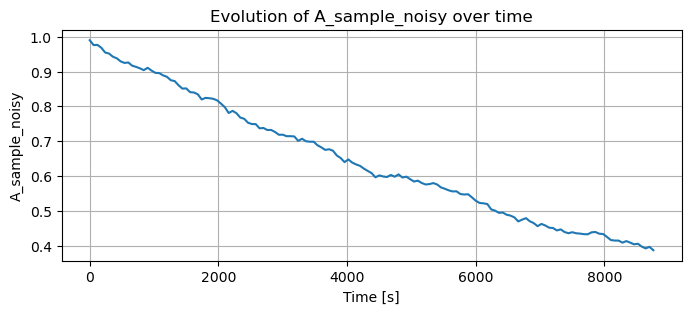

In [6]:
plt.figure(figsize=(8,3))
plt.plot(data['t'], data['A_sample_noisy'])
plt.xlabel("Time [s]")
plt.ylabel("A_sample_noisy")
plt.title("Evolution of A_sample_noisy over time")
plt.grid()
plt.show()

Lets see the ACF and the PACF to see how many lag variables should we add 

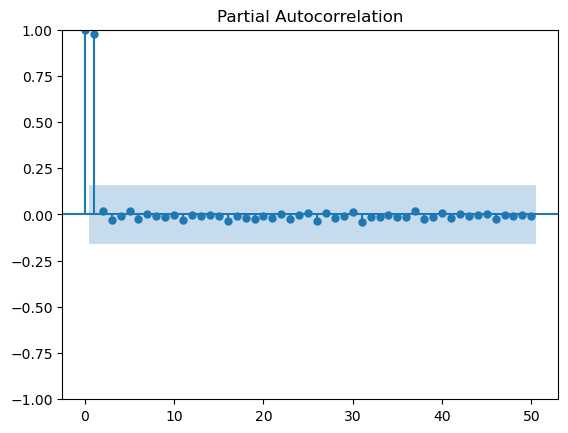

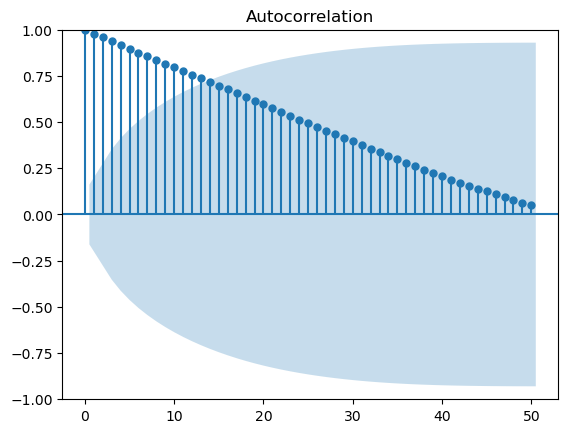

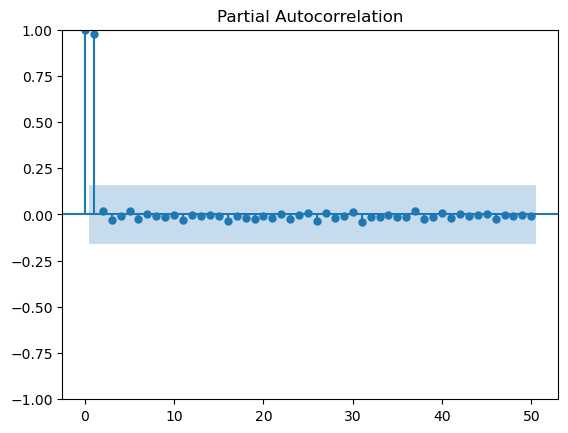

In [7]:
plot_acf(df['A_sample_noisy'], lags=50)
plot_pacf(df['A_sample_noisy'], lags=50)

> According to the PACF we will use only one target variable

In [8]:
data['A_sample_lag1'] = data['A_sample_noisy'].shift(1)

In [9]:
data.head()

,t,A_sample_noisy,A_sample_lag1
0,2.0,0.989995,NaN
1,62.0,0.976038,0.989995
2,122.0,0.976572,0.976038
3,182.0,0.968470,0.976572
4,242.0,0.954645,0.968470


In [10]:
data.to_csv("./Macro_lag_1.csv", index=False)

#### First : Predict the difference with the previous difference as a feature 

In [11]:
data['delta_y'] = data['A_sample_noisy'] - data['A_sample_lag1']

In [12]:
data['delta_y_lag1'] = data['delta_y'].shift(1)

In [13]:
data.head()

,t,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1
0,2.0,0.989995,NaN,NaN,NaN
1,62.0,0.976038,0.989995,-0.013957,NaN
2,122.0,0.976572,0.976038,0.000534,-0.013957
3,182.0,0.968470,0.976572,-0.008102,0.000534
4,242.0,0.954645,0.968470,-0.013825,-0.008102


In [14]:
data = data.dropna()

In [15]:
data.to_csv("./Macro_lag_1_delta_y.csv", index=False)

#### Second :  Predict the difference with also lags as features

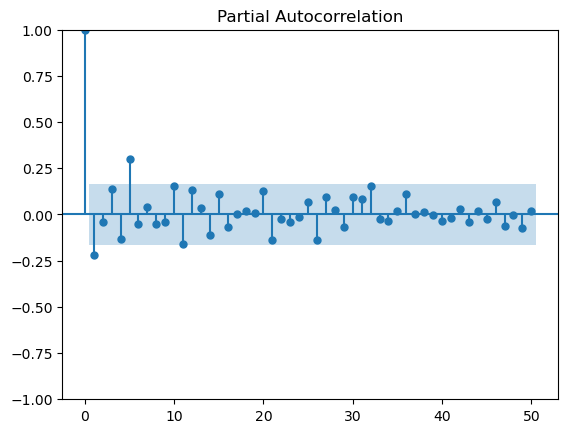

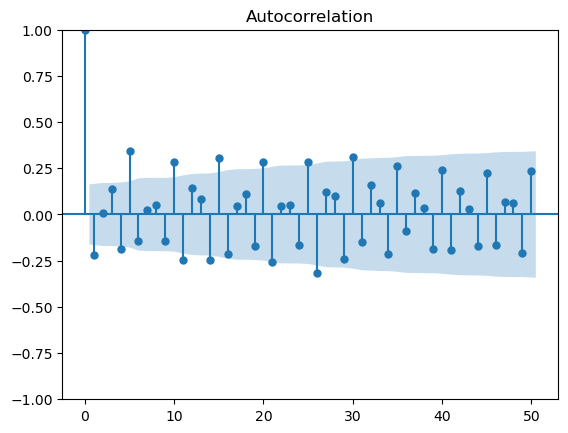

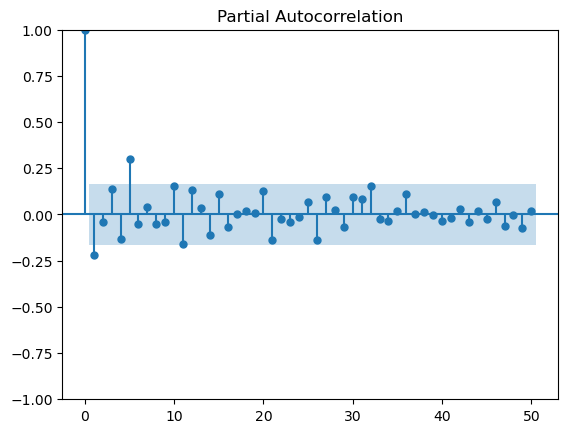

In [16]:
plot_acf(data['delta_y'], lags=50)
plot_pacf(data['delta_y'], lags=50)

> On va prendre les lags :  1, et 5

In [17]:
data_2 = data.copy()
data_2['delta_y_lag5'] = data_2['delta_y'].shift(5)
# data_2['delta_y_lag11'] = data_2['delta_y'].shift(11)
# data_2['delta_y_lag21'] = data_2['delta_y'].shift(21)
# data_2['delta_y_lag26'] = data_2['delta_y'].shift(26)
# data_2['delta_y_lag30'] = data_2['delta_y'].shift(30)
# data_2['delta_y_lag32'] = data_2['delta_y'].shift(32)

In [18]:
data_2.head(10)

,t,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1,delta_y_lag5
2,122.0,0.976572,0.976038,0.000534,-0.013957,NaN
3,182.0,0.968470,0.976572,-0.008102,0.000534,NaN
4,242.0,0.954645,0.968470,-0.013825,-0.008102,NaN
5,302.0,0.951726,0.954645,-0.002918,-0.013825,NaN
6,362.0,0.942669,0.951726,-0.009057,-0.002918,NaN
7,422.0,0.938089,0.942669,-0.004581,-0.009057,0.000534
8,482.0,0.929299,0.938089,-0.008790,-0.004581,-0.008102
9,542.0,0.924808,0.929299,-0.004491,-0.008790,-0.013825
10,602.0,0.926087,0.924808,0.001279,-0.004491,-0.002918
11,662.0,0.916821,0.926087,-0.009266,0.001279,-0.009057


In [19]:
data_2 = data_2.dropna()

In [20]:
data_2.to_csv("./Macro_lag_1_delta_y_delta_lags.csv", index=False)

In [21]:
data_2.head()

,t,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1,delta_y_lag5
7,422.0,0.938089,0.942669,-0.004581,-0.009057,0.000534
8,482.0,0.929299,0.938089,-0.008790,-0.004581,-0.008102
9,542.0,0.924808,0.929299,-0.004491,-0.008790,-0.013825
10,602.0,0.926087,0.924808,0.001279,-0.004491,-0.002918
11,662.0,0.916821,0.926087,-0.009266,0.001279,-0.009057


### Functions and Defenitions

In [22]:
def mean_absolute_percentage_error(y_true, y_pred): 
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [23]:
def compute_smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(
        2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))
    ) * 100

In [24]:
def compute_nrmse(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return rmse / (np.max(y_true) - np.min(y_true)) 

In [25]:
def save_experiment_results(
    part,
    model_name,
    method,
    mae,
    nrmse,
    rmse,
    smape,
    r2,
    train_time,
    pred_time,
    file_path="../results.csv"
):
    new_data = {
        "part": part,
        "model": model_name,
        "method": method,
        "mae": mae,
        "nrmse": nrmse,
        "rmse": rmse,
        "smape": smape,
        "r2": r2,
        "train_time": train_time,
        "pred_time": pred_time
    }

    new_row = pd.DataFrame([new_data])

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df = pd.concat([df, new_row], ignore_index=True)
    else:
        df = new_row

    df.to_csv(file_path, index=False)

    print("Results saved successfully!")

In [26]:
def save_model(model, model_name, part, method, folder="../saved_models"):
    os.makedirs(folder, exist_ok=True)

    filename = f"{model_name}_{part}_{method}.pkl"
    path = os.path.join(folder, filename)

    joblib.dump(model, path)

    print(f"Model saved at: {path}")

### Data Splitting 

In [27]:
data = data.set_index('t')
data_2 = data_2.set_index('t')

In [28]:
split = int(len(data) * 0.8)
data.iloc[split]

A_sample_noisy    0.457939
A_sample_lag1     0.462388
delta_y          -0.004449
delta_y_lag1      0.006458
Name: 7082.0, dtype: float64

In [29]:
split = int(len(data_2) * 0.8)
data_2.iloc[split]

A_sample_noisy    0.451596
A_sample_lag1     0.457939
delta_y          -0.006342
delta_y_lag1     -0.004449
delta_y_lag5     -0.008937
Name: 7142.0, dtype: float64

In [30]:
train = data.loc[data.index < 7082] # 20 % pour test et 80 % pour train
test = data.loc[data.index >= 7082]

train_2 = data_2.loc[data_2.index < 7142] # 20 % pour test et 80 % pour train
test_2 = data_2.loc[data_2.index >= 7142]

In [31]:
FEATURES = ['delta_y_lag1']
TARGET = 'delta_y'

X_train = train[FEATURES].reset_index(drop=True)
y_train = train[TARGET].copy().reset_index(drop=True)

X_test = test[FEATURES].copy().reset_index(drop=True)
y_test = test[TARGET].copy().reset_index(drop=True)

In [32]:
FEATURES_2 = ['delta_y_lag1','delta_y_lag5']
TARGET_2 = 'delta_y'

X_train_2 = train_2[FEATURES_2].reset_index(drop=True)
y_train_2 = train_2[TARGET_2].copy().reset_index(drop=True)

X_test_2 = test_2[FEATURES_2].copy().reset_index(drop=True)
y_test_2 = test_2[TARGET_2].copy().reset_index(drop=True)

In [33]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (116, 1)
Test size: (29, 1)


In [34]:
print("Train size:", X_train_2.shape)
print("Test size:", X_test_2.shape)

Train size: (112, 2)
Test size: (28, 2)


### Model Training

In [35]:
start_1 = time.perf_counter()
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

end_1 = time.perf_counter()
elapsed_time_training_1 = end_1 - start_1
print(f"Execution time of the training: {elapsed_time_training_1:.4f} seconds")

Execution time of the training: 0.6556 seconds


In [36]:
start_2 = time.perf_counter()

rf_2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_2.fit(X_train_2, y_train_2)

end_2 = time.perf_counter()
elapsed_time_training_2 = end_2 - start_2
print(f"Execution time of the training: {elapsed_time_training_2:.4f} seconds")

Execution time of the training: 0.5756 seconds


### Metrics Computation

1- On Delta_y

In [38]:
start_1_pred = time.perf_counter()
y_pred = rf.predict(X_test)
a_pred = y_pred + test['A_sample_lag1']
end_1_pred = time.perf_counter()
elapsed_time_1_pred = end_1_pred - start_1_pred
print(f"Execution time of the training: {elapsed_time_1_pred:.4f} seconds")

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
smape = compute_smape(y_test, y_pred)
nrmse = compute_nrmse(y_test, y_pred)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("sMape:",smape)
print("NRMSE",nrmse)

Execution time of the training: 0.1004 seconds
RMSE: 0.006082501491132055
MAE: 0.004379995986745372
R2: -1.0105842830553802
sMape: 110.6290557088897
NRMSE 0.3957459937214238


In [39]:
start_2_pred = time.perf_counter()
y_pred_2 = rf_2.predict(X_test_2)
a_pred_2 = y_pred_2 + test_2['A_sample_lag1']
end_2_pred = time.perf_counter()
elapsed_time_2_pred = end_2_pred - start_2_pred
print(f"Execution time of the training: {elapsed_time_2_pred:.4f} seconds")

mse = mean_squared_error(y_test_2, y_pred_2)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_2, y_pred_2)
r2 = r2_score(y_test_2, y_pred_2)
smape = compute_smape(y_test_2, y_pred_2)
nrmse = compute_nrmse(y_test_2, y_pred_2)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("sMape:",smape)
print("NRMSE",nrmse)

Execution time of the training: 0.0814 seconds
RMSE: 0.005192939206845899
MAE: 0.0042716669569623335
R2: -0.4243767963930243
sMape: 120.50090156965088
NRMSE 0.33786837368545997


2- On A_sample_noisy

In [40]:
a_true = test['A_sample_noisy']

mse = mean_squared_error(a_true, a_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(a_true, a_pred)
r2 = r2_score(a_true, a_pred)
smape = compute_smape(a_true, a_pred)
nrmse = compute_nrmse(a_true, a_pred)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("sMape:",smape)
print("NRMSE",nrmse)

RMSE: 0.006082501491132053
MAE: 0.00437999598674537
R2: 0.8983419631367671
sMape: 1.0476035383168543
NRMSE 0.08560662239968912


In [41]:
a_true_2 = test_2['A_sample_noisy']

mse = mean_squared_error(a_true_2, a_pred_2)
rmse = np.sqrt(mse)
mae = mean_absolute_error(a_true_2, a_pred_2)
r2 = r2_score(a_true_2, a_pred_2)
smape = compute_smape(a_true_2, a_pred_2)
nrmse = compute_nrmse(a_true_2,a_pred_2)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("sMape:",smape)
print("NRMSE",nrmse)

RMSE: 0.005192939206845899
MAE: 0.004271666956962336
R2: 0.919987844896605
sMape: 1.0143557474249376
NRMSE 0.08025028626917659


#### we save the model first 

In [42]:
save_model(
    model=rf_2,
    model_name="random_forest",
    part="macro",
    method="predict_delta_y"
)

Model saved at: ../saved_models\random_forest_macro_predict_delta_y.pkl


### Results 

Method : 1 -- Without lags

In [43]:
y_train_pred = rf.predict(X_train)
print("les valeurs réelle du train set avec les valeurs prédite\n")
train_set = train
train_set["delta_pred"] = y_train_pred
train_set["prédictions"] = y_train_pred + train_set['A_sample_lag1']
train_set.head()

les valeurs réelle du train set avec les valeurs prédite



,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1,delta_pred,prédictions
t,,,,,,
122.0,0.976572,0.976038,0.000534,-0.013957,-0.000379,0.975659
182.0,0.968470,0.976572,-0.008102,0.000534,-0.008126,0.968446
242.0,0.954645,0.968470,-0.013825,-0.008102,-0.009997,0.958473
302.0,0.951726,0.954645,-0.002918,-0.013825,-0.003270,0.951374
362.0,0.942669,0.951726,-0.009057,-0.002918,-0.006431,0.945295


In [44]:
print("les valeurs réelle du test set avec les valeurs prédite\n")
test_set = test
test_set["delta_pred"] = y_pred
test_set["prédictions"] = y_pred + test['A_sample_lag1']
test_set

les valeurs réelle du test set avec les valeurs prédite



,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1,delta_pred,prédictions
t,,,,,,
7082.0,0.457939,0.462388,-0.004449,0.006458,-0.008331,0.454057
7142.0,0.451596,0.457939,-0.006342,-0.004449,-0.001549,0.456389
7202.0,0.450712,0.451596,-0.000884,-0.006342,-0.001989,0.449607
7262.0,0.443687,0.450712,-0.007025,-0.000884,-0.005097,0.445614
7322.0,0.446733,0.443687,0.003046,-0.007025,-0.000559,0.443128
7382.0,0.439125,0.446733,-0.007608,0.003046,-0.005015,0.441718
7442.0,0.435690,0.439125,-0.003435,-0.007608,-0.004765,0.434360
7502.0,0.438615,0.435690,0.002925,-0.003435,-0.009405,0.426285
7562.0,0.435599,0.438615,-0.003016,0.002925,-0.005015,0.433599


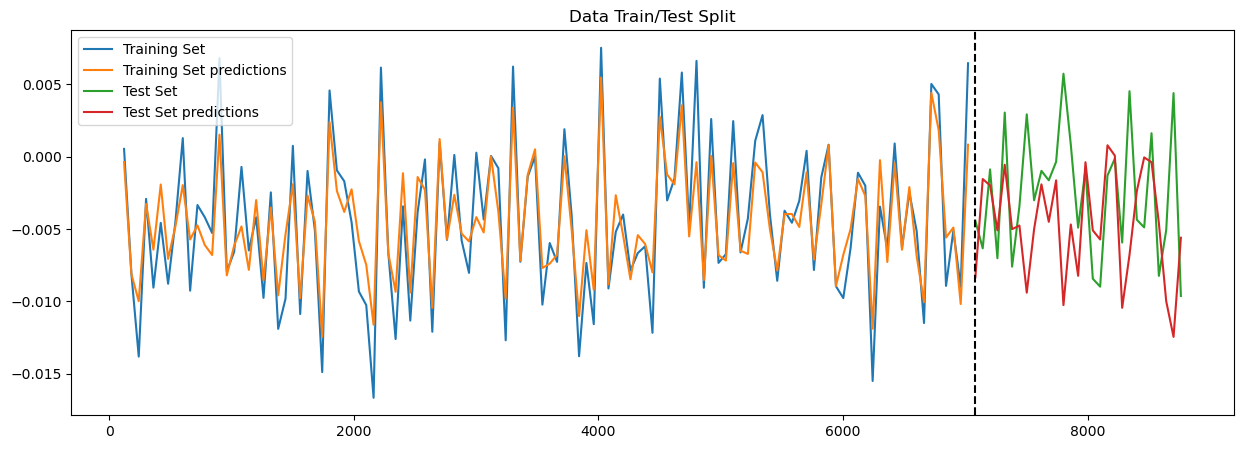

In [45]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(train.index,train["delta_y"], label='Training Set')
plt.plot(train.index,train_set["delta_pred"], label='Training Set predictions')
plt.plot(test.index,test["delta_y"],label='Test Set')
plt.plot(test.index,test_set["delta_pred"], label='Test Set prédictions')
ax.axvline(7082, color='black', ls='--')
plt.title('Data Train/Test Split')
ax.legend(['Training Set','Training Set predictions', 'Test Set', 'Test Set predictions'])
plt.show()

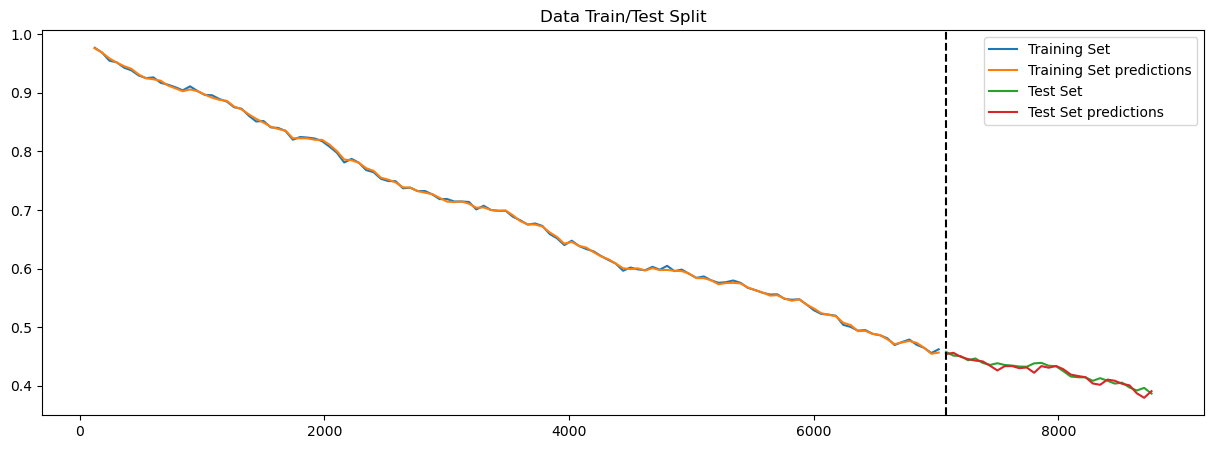

In [46]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(train.index,train["A_sample_noisy"], label='Training Set')
plt.plot(train.index,train_set["prédictions"], label='Training Set predictions')
plt.plot(test.index,test["A_sample_noisy"],label='Test Set')
plt.plot(test.index,test_set["prédictions"], label='Test Set prédictions')
ax.axvline(7082, color='black', ls='--')
plt.title('Data Train/Test Split')
ax.legend(['Training Set','Training Set predictions', 'Test Set', 'Test Set predictions'])
plt.show()

Method : 2 -- With delta_y lags

In [47]:
y_train_pred_2 = rf_2.predict(X_train_2)
print("les valeurs réelle du train set avec les valeurs prédite\n")
train_set_2 = train_2
train_set_2["delta_pred"] = y_train_pred_2
train_set_2["prédictions"] = y_train_pred_2 + train_set_2['A_sample_lag1']
train_set_2.head()

les valeurs réelle du train set avec les valeurs prédite



,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1,delta_y_lag5,delta_pred,prédictions
t,,,,,,,
422.0,0.938089,0.942669,-0.004581,-0.009057,0.000534,-0.004201,0.938469
482.0,0.929299,0.938089,-0.008790,-0.004581,-0.008102,-0.008814,0.929275
542.0,0.924808,0.929299,-0.004491,-0.008790,-0.013825,-0.004671,0.924628
602.0,0.926087,0.924808,0.001279,-0.004491,-0.002918,0.000021,0.924829
662.0,0.916821,0.926087,-0.009266,0.001279,-0.009057,-0.008400,0.917688


In [48]:
print("les valeurs réelle du test set avec les valeurs prédite\n")
test_set_2 = test_2
test_set_2["delta_pred"] = y_pred_2
test_set_2["prédictions"] = y_pred_2 + test_2['A_sample_lag1']
test_set_2

les valeurs réelle du test set avec les valeurs prédite



,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1,delta_y_lag5,delta_pred,prédictions
t,,,,,,,
7142.0,0.451596,0.457939,-0.006342,-0.004449,-0.008937,-0.011332,0.446607
7202.0,0.450712,0.451596,-0.000884,-0.006342,-0.005108,-0.006682,0.444914
7262.0,0.443687,0.450712,-0.007025,-0.000884,-0.008999,-0.012096,0.438615
7322.0,0.446733,0.443687,0.003046,-0.007025,0.006458,0.000203,0.443890
7382.0,0.439125,0.446733,-0.007608,0.003046,-0.004449,-0.006014,0.440719
7442.0,0.435690,0.439125,-0.003435,-0.007608,-0.006342,-0.007228,0.431897
7502.0,0.438615,0.435690,0.002925,-0.003435,-0.000884,-0.003099,0.432590
7562.0,0.435599,0.438615,-0.003016,0.002925,-0.007025,-0.001545,0.437069
7622.0,0.434615,0.435599,-0.000984,-0.003016,0.003046,-0.002941,0.432658


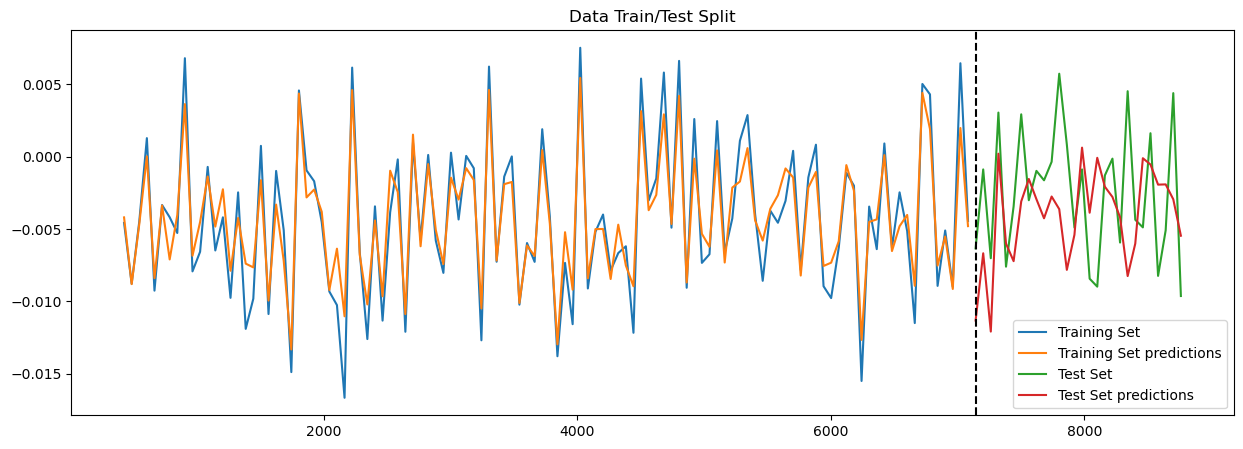

In [49]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(train_2.index,train_2["delta_y"], label='Training Set')
plt.plot(train_2.index,train_set_2["delta_pred"], label='Training Set predictions')
plt.plot(test_2.index,test_2["delta_y"],label='Test Set')
plt.plot(test_2.index,test_set_2["delta_pred"], label='Test Set prédictions')
ax.axvline(7142, color='black', ls='--')
plt.title('Data Train/Test Split')
ax.legend(['Training Set','Training Set predictions', 'Test Set', 'Test Set predictions'])
plt.show()

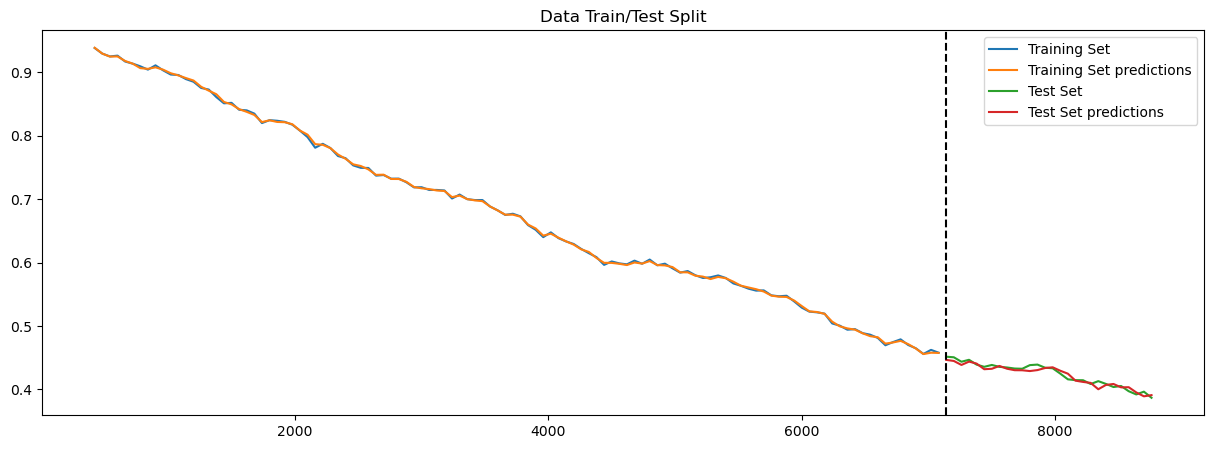

In [50]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(train_2.index,train_2["A_sample_noisy"], label='Training Set')
plt.plot(train_2.index,train_set_2["prédictions"], label='Training Set predictions')
plt.plot(test_2.index,test_2["A_sample_noisy"],label='Test Set')
plt.plot(test_2.index,test_set_2["prédictions"], label='Test Set prédictions')
ax.axvline(7142, color='black', ls='--')
plt.title('Data Train/Test Split')
ax.legend(['Training Set','Training Set predictions', 'Test Set', 'Test Set predictions'])
plt.show()

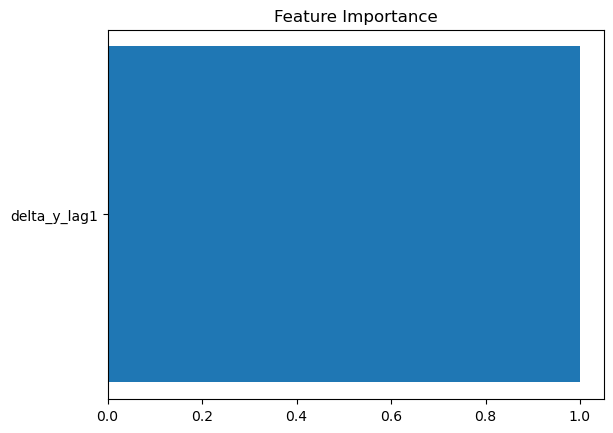

In [51]:
plt.barh(FEATURES, rf.feature_importances_)
plt.title("Feature Importance")
plt.show()

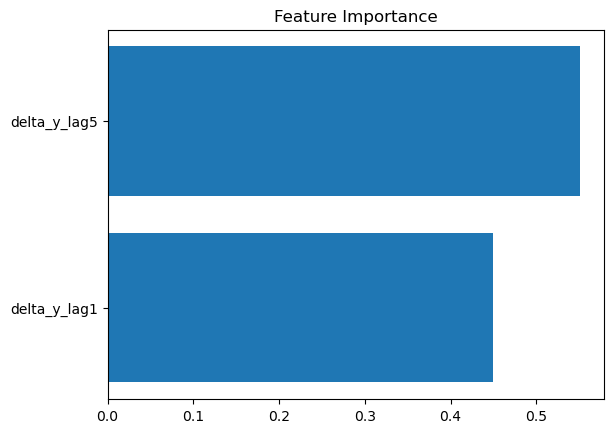

In [52]:
plt.barh(FEATURES_2, rf_2.feature_importances_)
plt.title("Feature Importance")
plt.show()

### Forecasts 

#### 1- Using the first model

In [53]:
last_row = train.iloc[-1].copy()
last_row

A_sample_noisy    0.462388
A_sample_lag1     0.455930
delta_y           0.006458
delta_y_lag1     -0.008999
delta_pred        0.000824
prédictions       0.456753
Name: 7022.0, dtype: float64

In [54]:
n_steps = 30

preds_recursive = []
new_row = last_row

for i in range(n_steps):
    
    lag1 = last_row['A_sample_lag1']
    delta_y_1 = last_row['delta_y_lag1']
    
    X_input = np.array([[delta_y_1]])
    
    delta_pred = rf.predict(X_input)[0]
    print(delta_pred)
    
    y_pred = lag1 + delta_pred
    
    preds_recursive.append(y_pred)
    
    new_row['A_sample_lag1'] = y_pred
    new_row['delta_y_lag1'] = delta_pred
    
    last_row = new_row

future_index = range(8762+ 1, 8762 + 1 + n_steps)
future_df= pd.DataFrame(preds_recursive,index=future_index)

0.0008236108371998904
-0.008950812566108406
-0.006795148903803886
-0.000448440053776388
-0.01069078837040359
-0.0050634916991303645
-0.012462808024287404
-0.001148403516809411
-0.002651949731187787
-0.009302650615897148
-0.007482430617622076
-0.009226832073371476
-0.004749309147434712
0.001545316742512734
-0.006651366772451924
-0.006083965834721468
-0.007373376293113276
-0.009215915971640998
-0.003887260341519382
-0.002989737298214434
-0.0019146185957408107
-0.010637759553498629
-0.00508488669045269
-0.012462808024287406
-0.001148403516809411
-0.002651949731187787
-0.009302650615897148
-0.007482430617622078
-0.009226832073371476
-0.004749309147434712


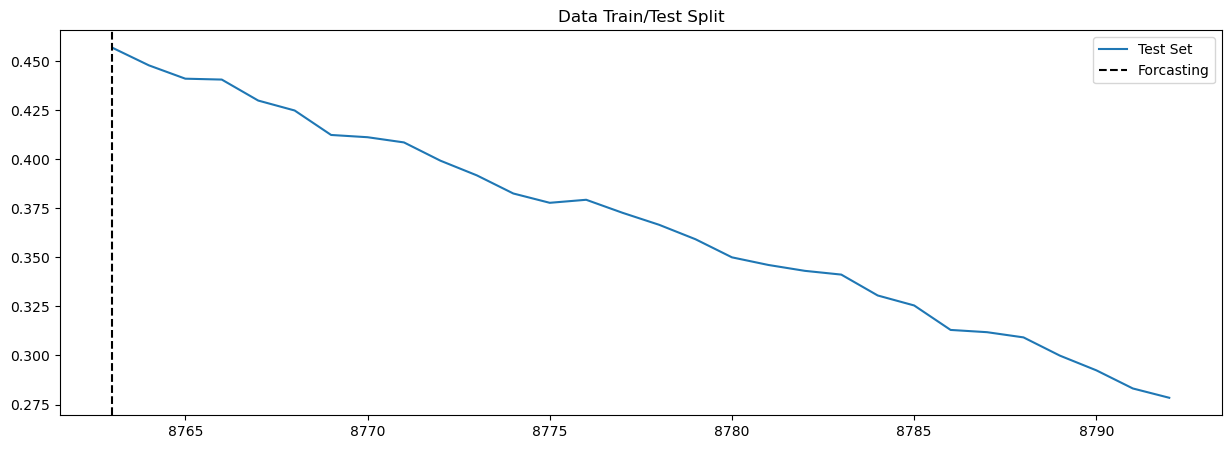

In [55]:
fig, ax = plt.subplots(figsize=(15, 5))
#plt.plot(test.index,test["A_sample_noisy"],label='Test Set')
#plt.plot(test.index,test_set["prédictions"], label='Test Set prédictions')
future_df.plot(ax=ax, label='Test Set forcasting')
ax.axvline(8763, color='black', ls='--')
plt.title('Data Train/Test Split')
ax.legend(['Test Set','Forcasting'])
plt.show()

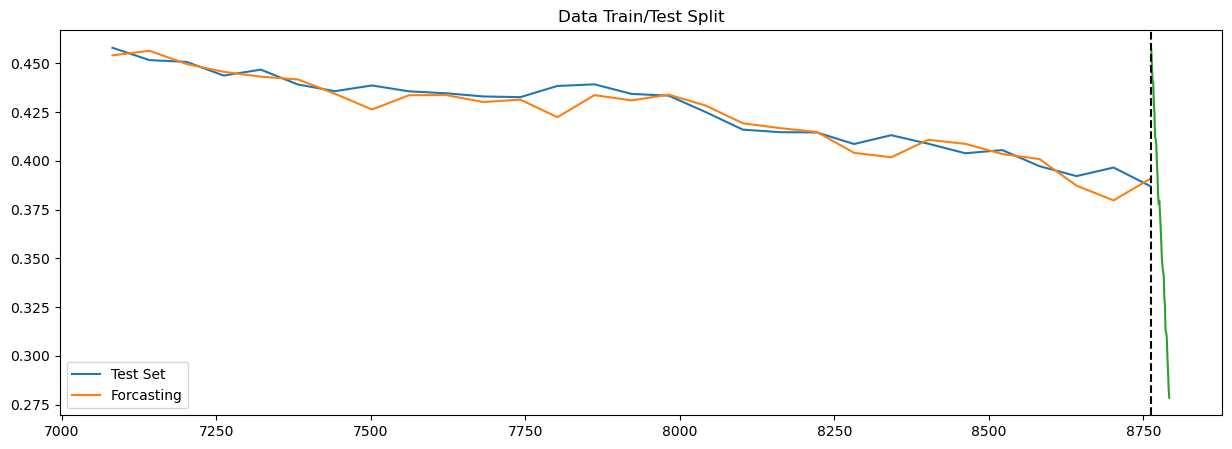

In [56]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(test.index,test["A_sample_noisy"],label='Test Set')
plt.plot(test.index,test_set["prédictions"], label='Test Set prédictions')
future_df.plot(ax=ax, label='Test Set forcasting')
ax.axvline(8763, color='black', ls='--')
plt.title('Data Train/Test Split')
ax.legend(['Test Set','Forcasting'])
plt.show()

#### 2- Forecasts using the second model 

In [56]:
last_row_2 = train_2.iloc[-5:].copy()
last_row_2

,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1,delta_y_lag5,delta_pred,prédictions
t,,,,,,,
6842.0,0.470036,0.478973,-0.008937,0.004303,-0.002470,-0.007534,0.471439
6902.0,0.464928,0.470036,-0.005108,-0.008937,-0.005148,-0.005521,0.464515
6962.0,0.455930,0.464928,-0.008999,-0.005108,-0.011508,-0.009150,0.455778
7022.0,0.462388,0.455930,0.006458,-0.008999,0.005024,0.001978,0.457908
7082.0,0.457939,0.462388,-0.004449,0.006458,0.004303,-0.004806,0.457582


In [58]:
n_steps = len(test_2)
preds_recursive_2 = []

y_history = list(train_2['A_sample_noisy'].iloc[-5:])

dy_history = list(train_2['delta_y'].iloc[-5:])

In [59]:
dy_history

[-0.008936625188506797,
 -0.005107516762227593,
 -0.008998669206611687,
 0.006457729008323476,
 -0.004449024207792807]

In [60]:
start_time_preds = time.perf_counter()

for i in range(n_steps):
    
    lag1 = y_history[-1]

    delta_y_lag1  = dy_history[-1]
    delta_y_lag5  = dy_history[-5]
    
    X_input = np.array([[
        delta_y_lag1,
        delta_y_lag5
    ]])
    
    # --- predict Δy ---
    delta_pred = rf_2.predict(X_input)[0]
    
    # --- reconstruct y ---
    y_pred = lag1 + delta_pred
    
    preds_recursive_2.append(y_pred)
    
    # --- update histories ---
    y_history.append(y_pred)
    dy_history.append(delta_pred)

end_time_preds = time.perf_counter()
elapsed_time_preds = end_time_preds - start_time_preds
print(f"Execution time of the training: {elapsed_time_preds:.4f} seconds")

future_df_2= pd.DataFrame(preds_recursive_2)

Execution time of the training: 1.5283 seconds


In [61]:
print(len(preds_recursive_2))

28


In [65]:
dy_history[-29:]

[-0.004449024207792807,
 -0.01133180119171608,
 -0.004842940785920461,
 -0.012016625878756997,
 0.00423987746586812,
 -0.006051894107148173,
 -0.0076258561494084165,
 -0.005676642275412686,
 -0.008176428219062327,
 -0.001655890594389413,
 0.0014315530358063057,
 -0.0034450793329704014,
 -0.0035950544596070983,
 -0.008323685737216884,
 -0.0020248126581415464,
 -0.002583668436840278,
 -0.00461450075738003,
 -0.0006106892980628537,
 -0.009551726049514061,
 -0.002562164963460551,
 -0.0043818176499786235,
 -0.003049621131890408,
 -0.005599958953801867,
 -0.011466350828375771,
 0.0020001289404473943,
 -0.005977752801063695,
 -0.0009490675683493985,
 -0.002737480849449847,
 -0.008003778768199467]

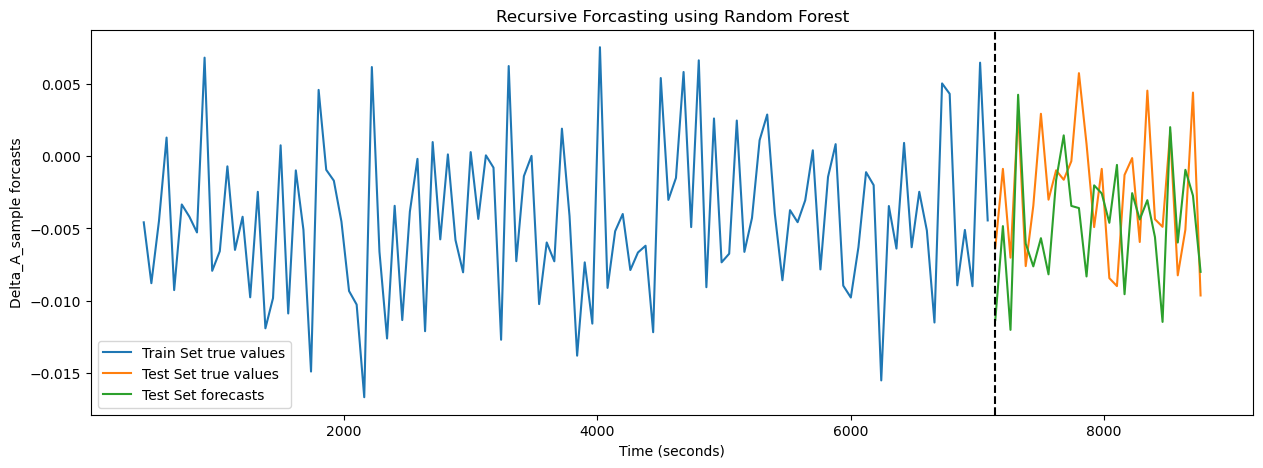

In [66]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(train_2.index,train_2["delta_y"],label='Train Set true values')
plt.plot(test_2.index,test_2["delta_y"],label='Test Set true values')
#plt.plot(test_2.index,test_set_2["prédictions"], label='Test Set prédictions')
plt.plot(test_2.index,dy_history[-28:], label='Test Set forecasts')
ax.axvline(7142, color='black', ls='--')
plt.xlabel("Time (seconds)")  
plt.ylabel("Delta_A_sample forcasts") 
plt.title('Recursive Forcasting using Random Forest')
ax.legend()
plt.show()

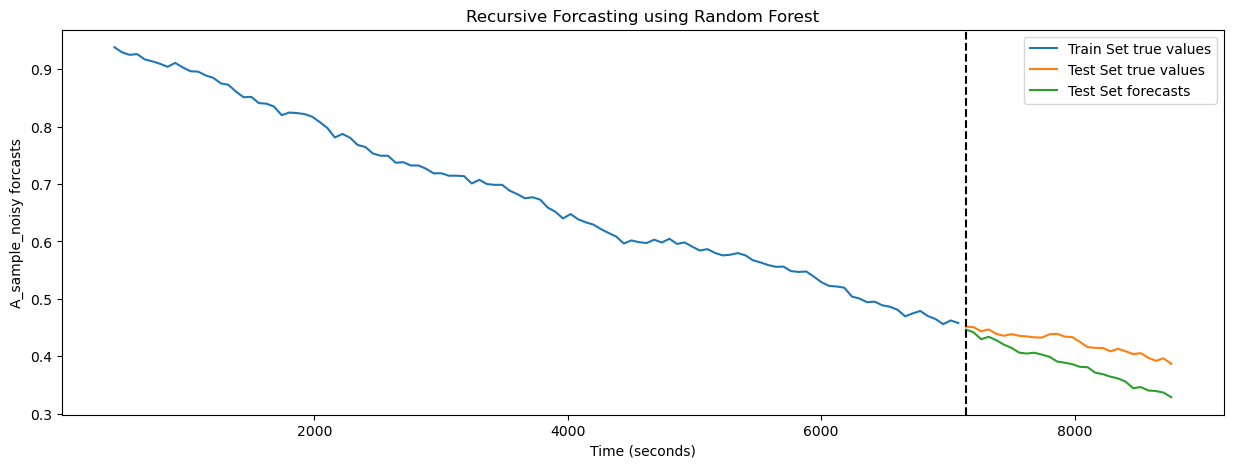

In [62]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(train_2.index,train_2["A_sample_noisy"],label='Train Set true values')
plt.plot(test_2.index,test_2["A_sample_noisy"],label='Test Set true values')
#plt.plot(test_2.index,test_set_2["prédictions"], label='Test Set prédictions')
plt.plot(test_2.index,preds_recursive_2, label='Test Set forecasts')
ax.axvline(7142, color='black', ls='--')
plt.xlabel("Time (seconds)")  
plt.ylabel("A_sample_noisy forcasts") 
plt.title('Recursive Forcasting using Random Forest')
ax.legend()
plt.show()

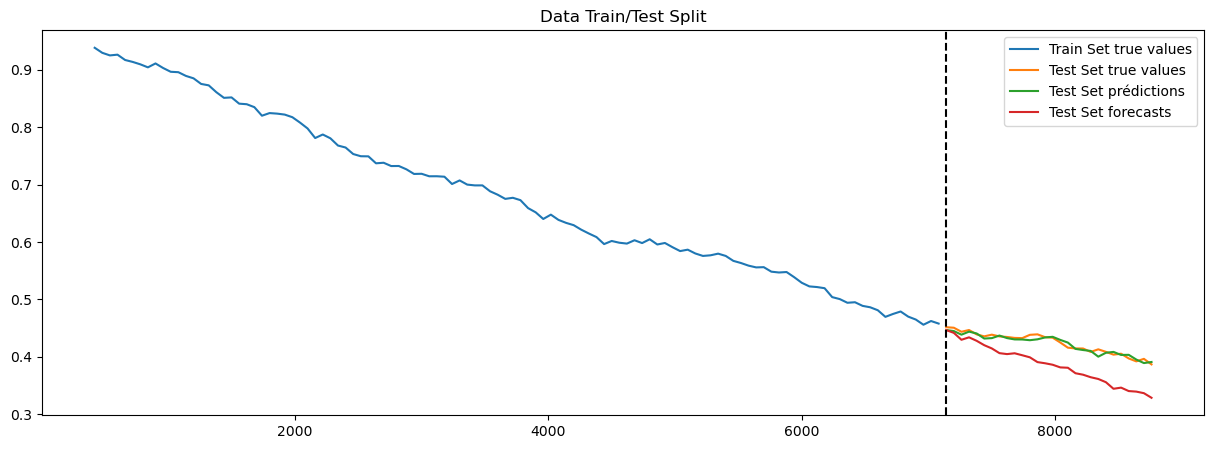

In [63]:
fig, ax = plt.subplots(figsize=(15, 5))
plt.plot(train_2.index,train_2["A_sample_noisy"],label='Train Set true values')
plt.plot(test_2.index,test_2["A_sample_noisy"],label='Test Set true values')
plt.plot(test_2.index,test_set_2["prédictions"], label='Test Set prédictions')
plt.plot(test_2.index,preds_recursive_2, label='Test Set forecasts')
ax.axvline(7142, color='black', ls='--')
plt.title('Data Train/Test Split')
ax.legend()
plt.show()

In [67]:
a_pred_2 = preds_recursive_2
a_true_2 = test_2['A_sample_noisy']

mse = mean_squared_error(a_true_2, a_pred_2)
rmse = np.sqrt(mse)
mae = mean_absolute_error(a_true_2, a_pred_2)
r2 = r2_score(a_true_2, a_pred_2)
smape = compute_smape(a_true_2, a_pred_2)
nrmse = compute_nrmse(a_true_2,a_pred_2)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("sMape:",smape)
print("NRMSE",nrmse)

RMSE: 0.04110074070127253
MAE: 0.037432288430711565
R2: -4.01220457576716
sMape: 9.524146797718934
NRMSE 0.6351597959791401


### Saving models and results 

In [68]:
save_experiment_results(
    part="macro",
    model_name="random_forest",
    method="predict_delta_y", 
    mae=mae,
    rmse=rmse,
    smape=smape,
    nrmse = nrmse,
    r2=r2,
    train_time=elapsed_time_training_2,
    pred_time=elapsed_time_preds
)

Results saved successfully!


In [69]:
results_df = pd.DataFrame({
    "y_true": test_2['delta_y'].values,
    "y_pred": dy_history[-28:],
    "reconstructed" : preds_recursive_2
})

results_df.to_csv(os.path.join(model_dir, "predictions_random_forest_target_delta_y.csv"), index=False)